<a href="https://colab.research.google.com/github/AdithyaAnand24/SIMC-2026/blob/main/SIMC_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 3

In [ ]:
#Module purpose. Question 3a, part (i): detect and remove the corrupted "empty vial" measurements from the spectroscopy design matrix mystery_matrix1.npy.

'''Data contract / assumptions.
  - The file loads as a float64 array of shape (3401, 1000). The problem defines the design matrix X with samples as rows (N = 1000 vials) and features as
  columns (frequencies). The on-disk array is therefore transposed relative to that convention: its 1000 axis is the samples. We transpose once, up front,
  so that downstream code follows the report's row = sample convention. (Note: the problem text states M = 3041 features; the actual file has 3401 columns.
  We use the array's true dimension and flag the discrepancy rather than hard-coding either number.)
  - All entries are non-negative intensities in [0, ~0.85]; there are no NaN/inf values. This is asserted, not assumed silently.

  Detection method. Each measurement is reduced to a single scalar, its row norm ‖xᵢ‖₂ = total signal energy across all frequencies. A real sample has
  absorption peaks (high norm); an empty vial is low background noise everywhere (low norm). The norm distribution is bimodal with an empty gap, so a hard
  threshold placed anywhere inside the gap separates the two populations exactly.

  Threshold choice & robustness. The cutoff is 3.0, but the result is invariant to any threshold in [2.0, 4.0] because the gap is genuinely empty. This
  invariance is checked explicitly — it is the evidence that the cut is principled rather than arbitrary.

  Validation strategy. Two independent checks: (1) summary statistics (mean/max/per-channel spread) must show the removed group is flat and low while the
  kept group has structure; (2) a visual overlay of removed vs kept spectra must show flat noise vs clear peaks.

  Outputs. T (number removed, expected 40), a boolean mask empty, the cleaned matrix S_clean (960 × 3401), and a figure q3a_part_i.png. The cleaned matrix
  is the input to 3b onward.'''



In [ ]:
 #Cell 1 — Imports

import numpy as np
import matplotlib.pyplot as plt
DATA_PATH = "/mystery_matrix1.npy"


In [ ]:
#Cell 2 — Load and sanity-check the raw array

# Load the raw design-matrix file.
# NOTE: the file is stored as (3401, 1000). The problem convention is
# samples-as-rows with N = 1000 vials, so the file is effectively X^T.
raw = np.load(DATA_PATH)

print("raw shape :", raw.shape)
print("dtype     :", raw.dtype)
print("min / max :", raw.min(), raw.max())
print("NaN / inf :", np.isnan(raw).any(), np.isinf(raw).any())

# The problem states M = 3041 features; the file has 3401. We trust the file
# and key off the axis whose length is 1000 (the samples).
assert 1000 in raw.shape, "expected one axis to be the 1000 samples"



raw shape : (3401, 1000)
dtype     : float64
min / max : 0.0 0.84962020625701
NaN / inf : False False


In [ ]:
#Cell 3 — Orient to "samples as rows"

# Transpose if necessary so that rows = samples (vials), cols = frequencies.
S = raw.T if raw.shape[0] != 1000 else raw
N, M = S.shape
print(f"design matrix oriented: {N} samples (rows) x {M} frequencies (cols)")



design matrix oriented: 1000 samples (rows) x 3401 frequencies (cols)


In [ ]:
#Cell 4 — Reduce each measurement to its row norm

# Row norm = total signal energy of one vial across all frequencies.
# Empty vials (background noise only) have small norm; real samples have peaks.
norms = np.linalg.norm(S, axis=1)
print("row-norm summary")
print("  min   :", norms.min())
print("  max   :", norms.max())
print("  mean  :", norms.mean())
print("  median:", np.median(norms))



row-norm summary
  min   : 1.5803901843168735
  max   : 8.918612708032397
  mean  : 5.845736205476745
  median: 5.785800341598418


In [ ]:
#Cell 5 — Inspect the distribution (find the gap)
# A text histogram makes the bimodal structure and the empty gap obvious.
hist, edges = np.histogram(norms, bins=40)
for h, e in zip(hist, edges[:-1]):
  print(f"  {e:5.2f} : {'#' * h} {h}")
# A tight clump of 40 sits at ~1.58-1.76, then an empty gap until ~4.15.



   1.58 : ######################################## 40
   1.76 :  0
   1.95 :  0
   2.13 :  0
   2.31 :  0
   2.50 :  0
   2.68 :  0
   2.86 :  0
   3.05 :  0
   3.23 :  0
   3.41 :  0
   3.60 :  0
   3.78 :  0
   3.97 :  0
   4.15 : ####### 7
   4.33 : ############################## 30
   4.52 :  0
   4.70 : ##################################################### 53
   4.88 : ########################################################## 58
   5.07 : ################################### 35
   5.25 : ################################################################################################################ 112
   5.43 : ############################################## 46
   5.62 : ######################################################################################################################################## 136
   5.80 : ########################################### 43
   5.98 : ######################################################################## 72
   6.17 : #####################

In [ ]:
#Cell 6 — Threshold and confirm robustness
#The empty-vial clump is well below the real samples. Any threshold inside the
#gap gives the same count, which is the evidence the cut is not arbitrary.
for thr in (2.0, 3.0, 4.0):
    print(f"  rows with norm < {thr}: {(norms < thr).sum()}")  # all 40

THRESHOLD = 3.0
empty = norms < THRESHOLD          # boolean mask of corrupted measurements
real  = ~empty

T = int(empty.sum())
print(f"\nT = {T} corrupted (empty-vial) measurements")
print("their norm range:", norms[empty].min(), "->", norms[empty].max())
print("remaining measurements:", int(real.sum()))   # 960



  rows with norm < 2.0: 40
  rows with norm < 3.0: 40
  rows with norm < 4.0: 40

T = 40 corrupted (empty-vial) measurements
their norm range: 1.5803901843168735 -> 1.7048182565098327
remaining measurements: 960


In [22]:
#Cell 7 — Validate the removal (statistics)
# Removed group should be flat & low; kept group should have structure (peaks).
def describe(mask, label):
  print(f"{label:12s}: mean/chan = {S[mask].mean():.4f}  "
      f"max = {S[mask].max():.4f}  "
      f"per-channel std = {S[mask].std(axis=1).mean():.4f}")
describe(empty, "empty (rm)")
describe(real,  "real (keep)")



empty (rm)  : mean/chan = 0.0159  max = 0.1826  per-channel std = 0.0234
real (keep) : mean/chan = 0.0639  max = 0.8496  per-channel std = 0.0809


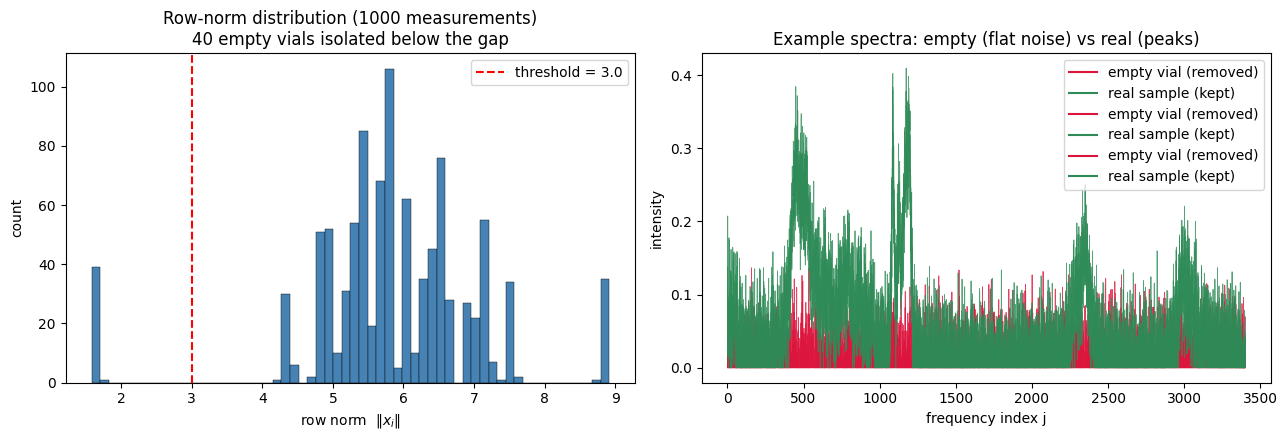

In [ ]:
#Cell 8 — Validate the removal (figure)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: row-norm histogram with the threshold marked.
ax[0].hist(norms, bins=60, color="steelblue", edgecolor="k", linewidth=0.3)
ax[0].axvline(THRESHOLD, color="red", ls="--", label=f"threshold = {THRESHOLD}")
ax[0].set_xlabel(r"row norm  $\|x_i\|$")
ax[0].set_ylabel("count")
ax[0].set_title(f"Row-norm distribution (1000 measurements)\n"
                f"{T} empty vials isolated below the gap")
ax[0].legend()

# Right: example removed (empty) vs kept (real) spectra.
for i in np.where(empty)[0][:3]:
  ax[1].plot(S[i], color="crimson",  lw=0.6, alpha=0.8)
for i in np.where(real)[0][:3]:
  ax[1].plot(S[i], color="seagreen", lw=0.6, alpha=0.8)
  ax[1].plot([], [], color="crimson",  label="empty vial (removed)")
  ax[1].plot([], [], color="seagreen", label="real sample (kept)")
  ax[1].set_xlabel("frequency index j")
  ax[1].set_ylabel("intensity")
  ax[1].set_title("Example spectra: empty (flat noise) vs real (peaks)")
  ax[1].legend()

plt.tight_layout()
plt.savefig("q3a_part_i.png", dpi=120)
plt.show()



In [ ]:
#Cell 9 — Produce the cleaned matrix for downstream parts

  # Cleaned design matrix after removing the T empty-vial measurements.
  # This (960 x 3401) array is the input to 3a(ii) and 3b onward.
S_clean = S[real]
print("cleaned design matrix:", S_clean.shape)   # (960, 3401)

cleaned design matrix: (960, 3401)
